In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df = pd.read_csv(
    "/content/Reviews.csv",
    engine="python",
    on_bad_lines='skip'
)


In [ ]:
# 1. Fill missing values
df['Text'] = df['Text'].fillna("")
df['Score'] = df['Score'].fillna(0)
df['HelpfulnessNumerator'] = df['HelpfulnessNumerator'].fillna(0)
df['HelpfulnessDenominator'] = df['HelpfulnessDenominator'].fillna(0)


# 2. Labeling function
def label_review(row):
    text = row['Text']
    score = int(row['Score'])
    h_n = int(row['HelpfulnessNumerator'])
    h_d = int(row['HelpfulnessDenominator'])

    # Extra fix for empty text
    if text.strip() == "":
        return 0  # Consider empty review as fake

    short = len(text.split()) < 40
    no_help = (h_n == 0 and h_d == 0)

    if score in [1,5] and short and no_help:
        return 0  # Fake
    else:
        return 1  # Genuine

df['Label'] = df.apply(label_review, axis=1)
df['Label'].value_counts()


,count
Label,
1,118342
0,19102


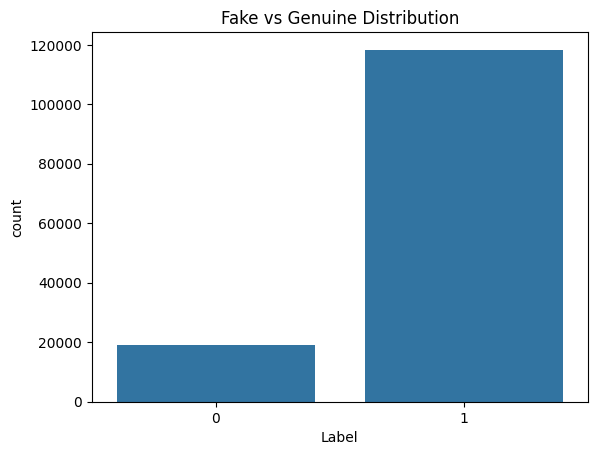

In [ ]:
sns.countplot(data=df, x='Label')
plt.title("Fake vs Genuine Distribution")
plt.show()


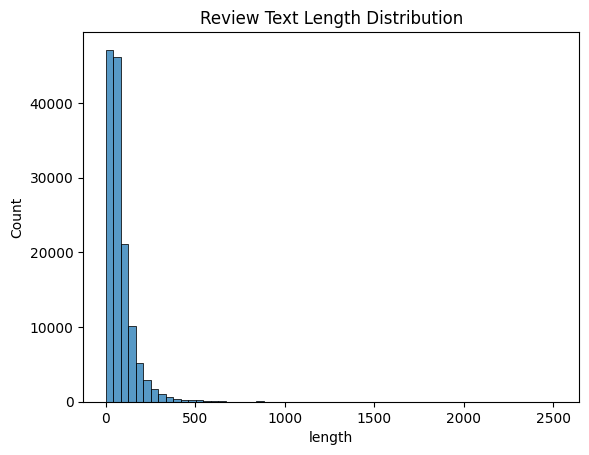

In [ ]:
df['length'] = df['Text'].apply(lambda x: len(x.split()))
sns.histplot(df['length'], bins=60)
plt.title("Review Text Length Distribution")
plt.show()


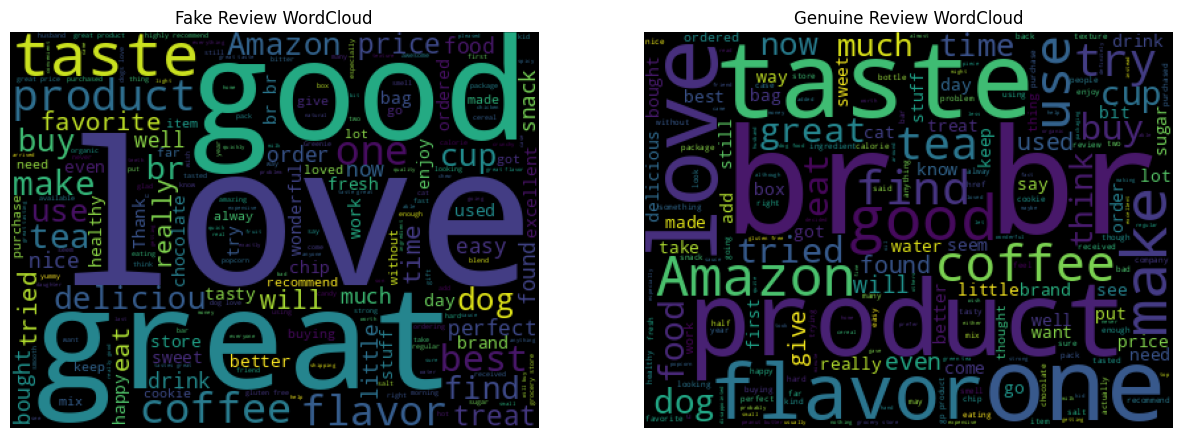

In [ ]:
from wordcloud import WordCloud

fake_text = " ".join(df[df['Label']==0]['Text'])
genuine_text = " ".join(df[df['Label']==1]['Text'])

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400,height=300).generate(fake_text))
plt.title("Fake Review WordCloud")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=400,height=300).generate(genuine_text))
plt.title("Genuine Review WordCloud")
plt.axis('off')

plt.show()


In [ ]:
stop_words = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = [lemm.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['Text'].apply(clean_text)
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Label,length,cleaned
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...,1,48,bought several vitality canned dog food produc...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0,31,product arrived labeled jumbo salted peanut pe...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...,1,94,confection around century light pillowy citrus...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...,1,41,looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...,0,27,great taffy great price wide assortment yummy ...


In [ ]:
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['cleaned'])
y = df['Label']


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, stratify=y_res
)


In [ ]:
params = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

nb = MultinomialNB()

grid = GridSearchCV(nb, params, cv=5, n_jobs=-1, scoring='accuracy')
grid.fit(X_train, y_train)

print("BEST PARAMS:", grid.best_params_)
model = grid.best_estimator_


BEST PARAMS: {'alpha': 0.1, 'fit_prior': True}


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7863142417738419

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79     29586
           1       0.79      0.77      0.78     29585

    accuracy                           0.79     59171
   macro avg       0.79      0.79      0.79     59171
weighted avg       0.79      0.79      0.79     59171



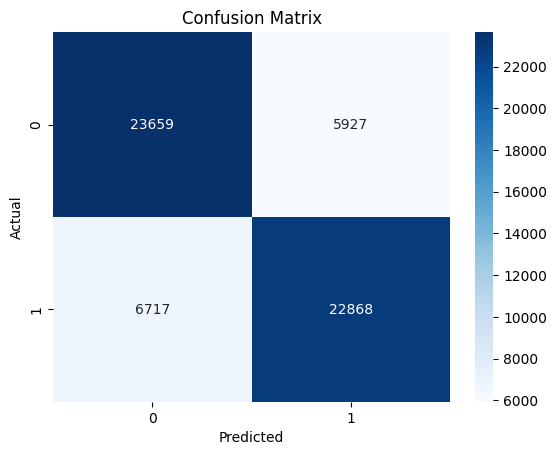

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')

print("CV Mean Accuracy:", scores.mean())
print("CV Scores:", scores)


CV Mean Accuracy: 0.7842355208169068
CV Scores: [0.78653062 0.787101   0.78260135 0.78070009 0.78424455]


In [ ]:
def predict_review(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "Genuine Review ✅" if pred == 1 else "Fake Review ❌"

print(predict_review("Amazing product, totally loved it!"))
print(predict_review("Good."))


Fake Review ❌
Fake Review ❌
